<a href="https://colab.research.google.com/github/ElihuIzanami/Fundamentos-de-Python/blob/main/Estad%C3%ADstica_Diferencial_e_Inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Estadístico de Datos

## Análisis Univariable

El análisis univariable se enfoca en una sola característica a la vez. No busca explicar "por qué" pasa algo, sino "qué" está pasando con esa variable.

 # Medidas de Tendencia Central
Son parámetros estadísticos que resumen un conjunto de datos en un solo valor, indicando el centro de la distribución

**Media (.mean()):**  Explicación: Es el promedio aritmético. Se suman todos los valores y se dividen entre el total.

Uso: Se usa cuando los datos son parecidos entre sí. Es muy sensible a valores "mentirosos" (muy altos o muy bajos).

**Mediana (.median()):** Explicación: Es el valor exacto del centro cuando ordenas los datos de menor a mayor. Deja el 50% de los datos a la izquierda y el 50% a la derecha.

Uso: Es la mejor medida cuando tienes valores extremos (outliers), ya que no se deja "engañar" por ellos.

**Moda (.mode()):** Explicación: Es el valor que ocurre con mayor frecuencia.

Uso: Útil para saber qué es lo más popular o común (ej. el plato más pedido en un restaurante).

# Ejercicio:

Tienes un dataset con los ingresos mensuales de empleados de una empresa. El objetivo es:

Analizar una sola variable: **ingreso**

Calcular:

*    Media
*  Moda

*   Mediana

Visualizar la distribución

Detectar posibles outliers


Media: 1906.6666666666667
Mediana: 1700.0
Moda: [1200 1250 1300 1350 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300
 5000]


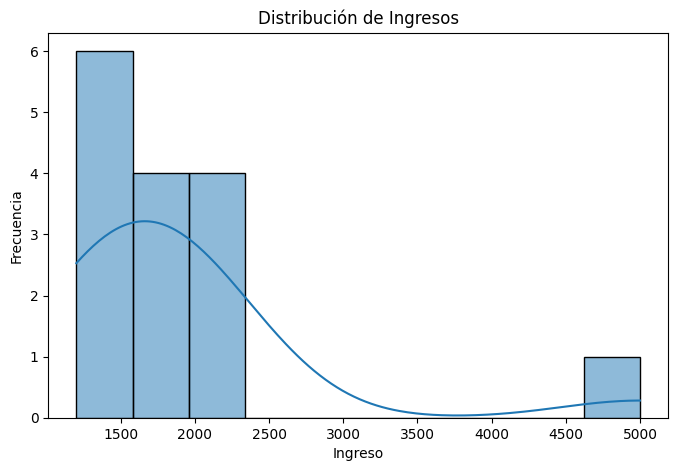

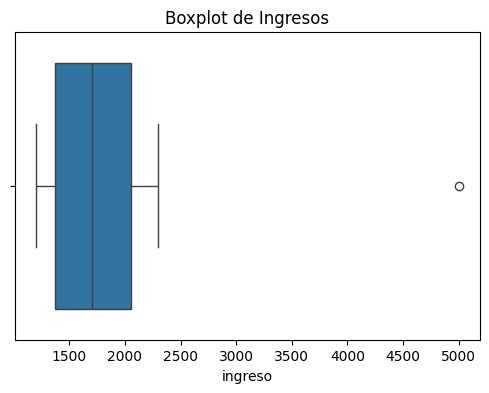

In [ ]:
# 1. IMPORTAR LIBRERÍAS
import pandas as pd              # Para manipulación de datos
import matplotlib.pyplot as plt  # Para gráficos básicos
import seaborn as sns            # Para gráficos estadísticos más avanzados

# 2. CREAR DATASET
data = {
    "ingreso": [1200, 1300, 1250, 1400, 1350, 1500, 1600, 1700,
                1800, 1900, 2000, 2100, 2200, 2300, 5000]  # 5000 es un outlier
}

df = pd.DataFrame(data)

# 🔹 MOSTRAR DATASET (tipo tabla estilo Excel)
df

# 3. ANÁLISIS UNIVARIABLE

# Media
media = df["ingreso"].mean()

# Mediana
mediana = df["ingreso"].median()

# Moda
moda = df["ingreso"].mode()

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda.values)

# 4. VISUALIZACIÓN
# Histograma
plt.figure(figsize=(8,5))
sns.histplot(df["ingreso"], bins=10, kde=True)
plt.title("Distribución de Ingresos")
plt.xlabel("Ingreso")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot (para detectar outliers)
plt.figure(figsize=(6,4))
sns.boxplot(x=df["ingreso"])
plt.title("Boxplot de Ingresos")
plt.show()

# Medidas de Dispersión

**Varianza y Desviación Estándar:**

Una desviación estándar baja significa que la mayoría de los datos son similares al promedio; una alta indica mucha variedad.

**Percentiles:**

El conjunto de datos son divididos en 100 partes iguales, haciendo asociación a la escala de porcentaje. Cada percentil representa un porcentaje de dicho conjunto.

**Tipos de Percentiles**

•*Decil:* Los datos son agrupados en 10 conjuntos, asociándose en partes de 10% cada grupo.

•*Cuartil:* Los datos son agrupados en 4 conjuntos, asociando en partes de 25% cada grupo.


# Ejercicio:

Imagina que trabajas analizando máquinas que llenan botellas de 500ml. Queremos saber si la máquina es precisa o si está fallando.

In [ ]:
import numpy as np
import pandas as pd

# Datos: Mililitros reales en 10 botellas
datos_llenado = [502, 498, 499, 500, 501, 497, 503, 500, 499, 501]

# 1. Varianza y Desviación Estándar
varianza = np.var(datos_llenado)
desviacion_std = np.std(datos_llenado)

# 2. Percentiles (Cuartiles y Deciles)
# El Q2 (Cuartil 2) es el percentil 50 o la mediana
cuartiles = np.percentile(datos_llenado, [25, 50, 75])
decil_9 = np.percentile(datos_llenado, 90)

print(f"Desviación Estándar: {desviacion_std:.2f} ml")
print(f"Cuartiles (25%, 50%, 75%): {cuartiles}")
print(f"Decil 9 (El 90% de las botellas tienen menos de): {decil_9} ml")

Desviación Estándar: 1.73 ml
Cuartiles (25%, 50%, 75%): [499. 500. 501.]
Decil 9 (El 90% de las botellas tienen menos de): 502.1 ml


# Análisis de Bivariable

El análisis entre la relación de dos variables tiene como objetivo principal determinar si existe una asociación entre ellas y, de ser así, cuál es la fuerza y la dirección de esa relación.


Para este análisis, solemos clasificar las variables en:

•	Variable Independiente (X): La que suponemos que causa el cambio.

•	Variable Dependiente (Y): La que recibe el efecto.


Ejercicio:

Queremos saber si existe una relación entre las horas de estudio y la calificación final de un grupo de estudiantes.

In [ ]:
import pandas as pd
import numpy as np

# Generamos datos: a más horas, suele haber mejor nota (correlación positiva)
data = {
    'horas_estudio': [1, 2, 3, 5, 8, 10, 12, 15, 18, 20],
    'calificacion': [40, 45, 50, 60, 75, 82, 88, 92, 95, 98]
}

df_estudiantes = pd.DataFrame(data)

# 1. Cálculo de la Correlación de Pearson
correlacion = df_estudiantes['horas_estudio'].corr(df_estudiantes['calificacion'])

print(f"Coeficiente de Correlación: {correlacion:.4f}")

Coeficiente de Correlación: 0.9640


**Multivariable**

Una inmobiliaria quiere entender el precio de las casas basado en múltiples factores: Metros cuadrados, Antigüedad y Número de habitaciones.

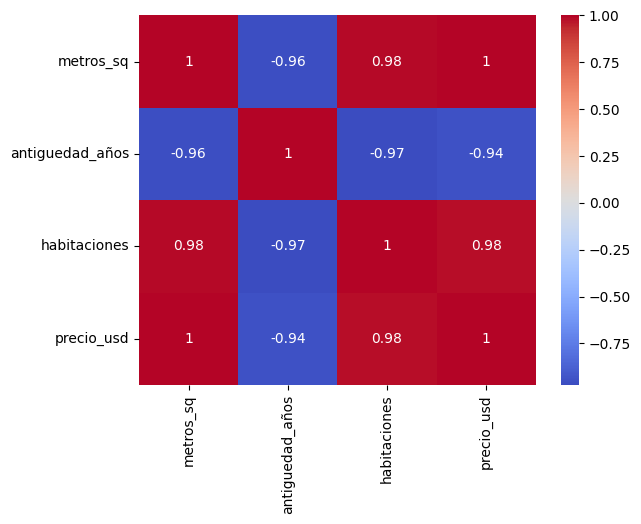

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset multivariable
data_casas = {
    'metros_sq': [50, 80, 120, 150, 200, 250],
    'antiguedad_años': [30, 20, 15, 10, 5, 2],
    'habitaciones': [1, 2, 3, 3, 4, 5],
    'precio_usd': [100, 150, 250, 320, 450, 600]
}

df_casas = pd.DataFrame(data_casas)

# 1. Matriz de Correlación
matriz = df_casas.corr()

# 2. Visualización Multivariable (Heatmap)
sns.heatmap(matriz, annot=True, cmap='coolwarm')
plt.show()

**Practica:**

Imagina que durante un mes registras todos tus gastos en restaurantes, cafeterías o pedidos de comida.

Quieres responder preguntas como:

¿Cuánto gasto en promedio?
¿Cuáles son los días donde gasto más?
¿Mis gastos son constantes o muy variables?
¿Cuánto debería presupuestar semanalmente?
¿Qué tan dispersos son mis gastos?

La estadística descriptiva permite responder todas estas preguntas usando datos reales.


   dia  gasto_total  personas  propina
0  Lun          120         1       20
1  Mar          150         2       25
2  Mie           90         1       10
3  Jue          200         2       30
4  Vie          350         4       50
5  Sab          500         5       80
6  Dom          300         3       40
INFORMACION DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   dia          7 non-null      object
 1   gasto_total  7 non-null      int64 
 2   personas     7 non-null      int64 
 3   propina      7 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 356.0+ bytes
None
ESTADISTICAS DESCRIPTIVAS
       gasto_total  personas    propina
count     7.000000  7.000000   7.000000
mean    244.285714  2.571429  36.428571
std     147.066554  1.511858  23.222526
min      90.000000  1.000000  10.000000
25%     135.000000  1.500000  22

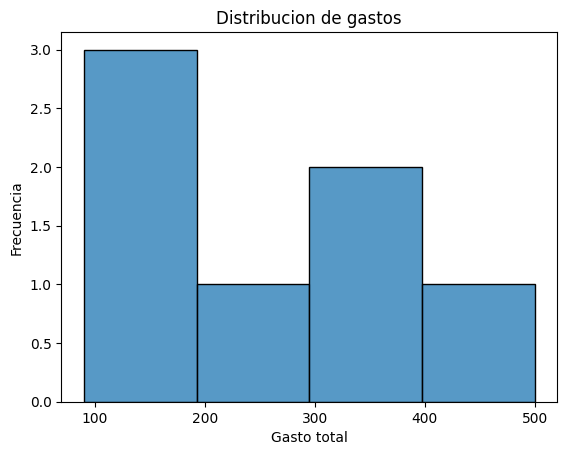

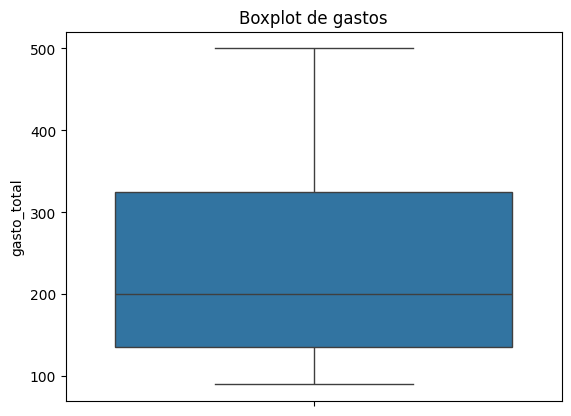

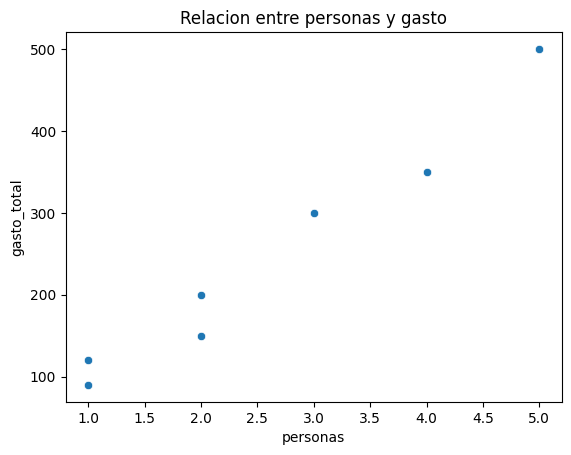

CONCLUSIONES
El gasto promedio semanal es: 244.28571428571428
La variabilidad de gastos es: 147.06655441864214
La cantidad mas frecuente de personas es:
0    1
1    2
Name: personas, dtype: int64


In [ ]:
# ANALISIS DE GASTOS PERSONALES

# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gastos = {
    'dia': ['Lun','Mar','Mie','Jue','Vie','Sab','Dom'],
    'gasto_total': [120, 150, 90, 200, 350, 500, 300],
    'personas': [1,2,1,2,4,5,3],
    'propina': [20,25,10,30,50,80,40]
}

_df = pd.DataFrame(gastos)

# Mostrar dataframe
print(_df)

# INFORMACION GENERAL

print("INFORMACION DEL DATASET")
print(_df.info())

# ESTADISTICA DESCRIPTIVA

print("ESTADISTICAS DESCRIPTIVAS")
print(_df.describe())

# MEDIDAS DE TENDENCIA CENTRAL

# Media
media_gasto = _df['gasto_total'].mean()
print("MEDIA DE GASTOS:", media_gasto)

# Mediana
mediana_gasto = _df['gasto_total'].median()
print("MEDIANA DE GASTOS:", mediana_gasto)

# Moda
moda_personas = _df['personas'].mode()
print("MODA DE PERSONAS:")
print(moda_personas)

# MEDIDAS DE DISPERSION
# Desviación estándar
std_gasto = _df['gasto_total'].std()
print("DESVIACION ESTANDAR:", std_gasto)

# Valor mínimo y máximo
print("GASTO MINIMO:", _df['gasto_total'].min())
print("GASTO MAXIMO:", _df['gasto_total'].max())

# VISUALIZACIONES

# Histograma
sns.histplot(_df['gasto_total'])
plt.title('Distribucion de gastos')
plt.xlabel('Gasto total')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot
sns.boxplot(y=_df['gasto_total'])
plt.title('Boxplot de gastos')
plt.show()

# Scatterplot
sns.scatterplot(x='personas', y='gasto_total', data=_df)
plt.title('Relacion entre personas y gasto')
plt.show()

# ANALISIS FINAL
print("CONCLUSIONES")
print("El gasto promedio semanal es:", media_gasto)
print("La variabilidad de gastos es:", std_gasto)
print("La cantidad mas frecuente de personas es:")
print(moda_personas)

**Challege Estadistica Descriptiva**

### **INSTRUCCIONES:**
**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

**3. Muestra los datos generales del dataset:**

   * Muestra las propiedades del dataset.
   * Muestra el resumen estadístico del dataset.

**4. Realiza un análisis de univariable:**

   * Cálcula las medidas de tendencia central de la columna total.
   * Cálcula las medidas de dispersión de la columna total.
   * Visualiza los gráficos de las medidas obtenidas en un subplot de 3 columnas.

   **5. Realiza un análisis de multivariable:** Visualiza en un mapa de calor los coeficientes de correlación para todos los pares posibles de las columnas numéricas del dataset.

  **6. Realiza un análisis de bivariable:**

   * Cálcula los coeficientes de correlación de pearson de las 3 correlaciones mas fuertes obtenidas en el gráfico de calor.
   * Visualiza los gráficos de las correlaciones obtenidas en un subplot de 3 columnas.

--- Propiedades del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datet

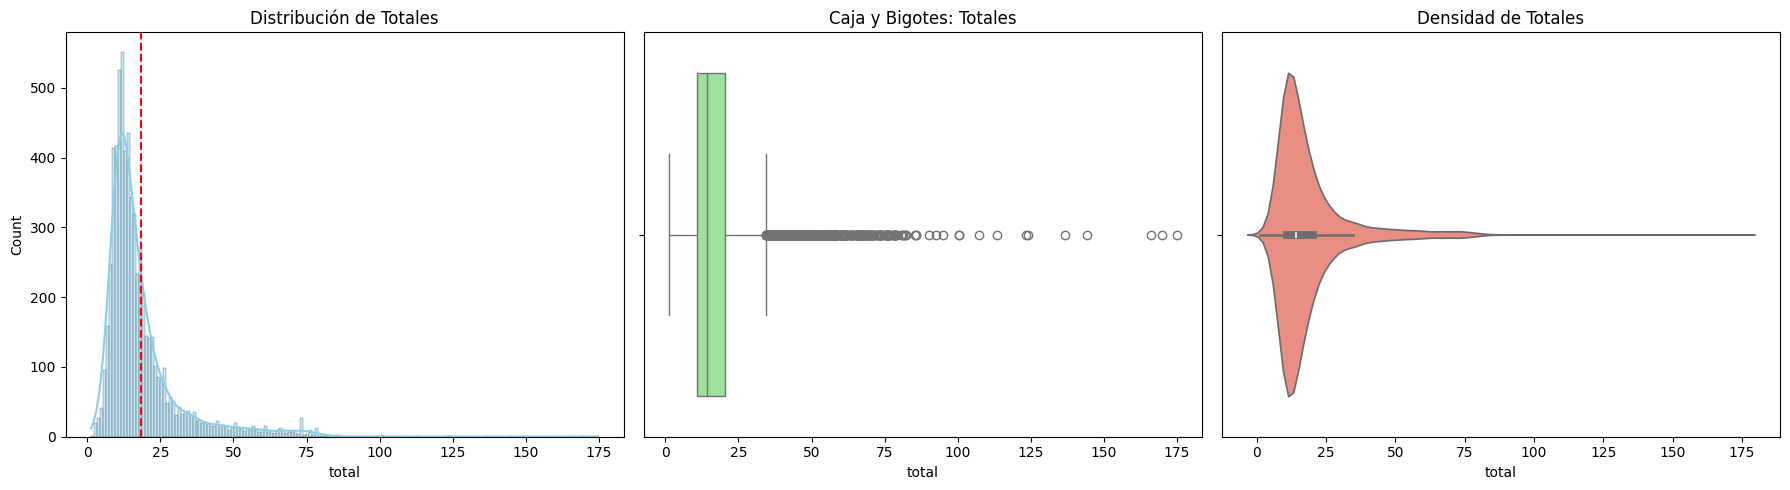

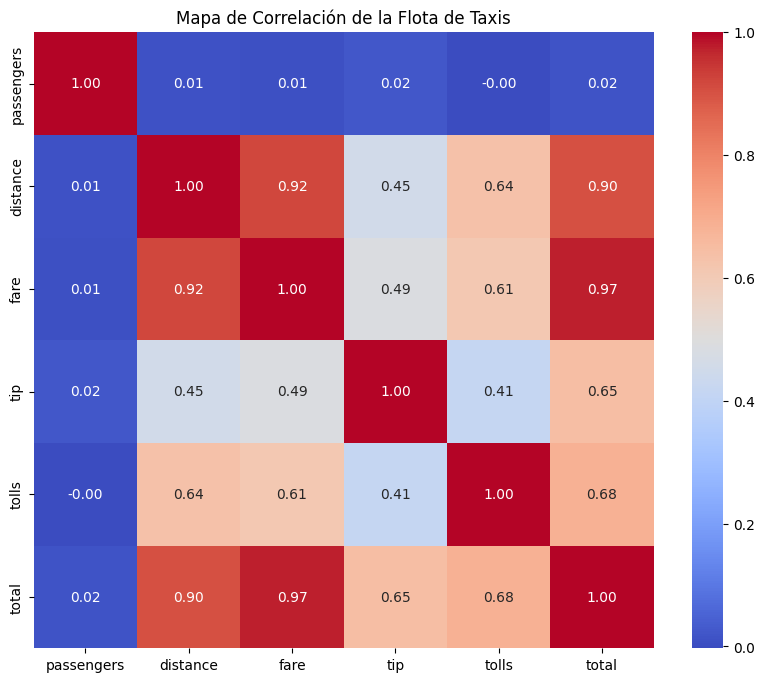


--- Coeficientes de Pearson ---
Distancia vs Tarifa: 0.9201
Distancia vs Total: 0.9047
Tarifa vs Total: 0.9744


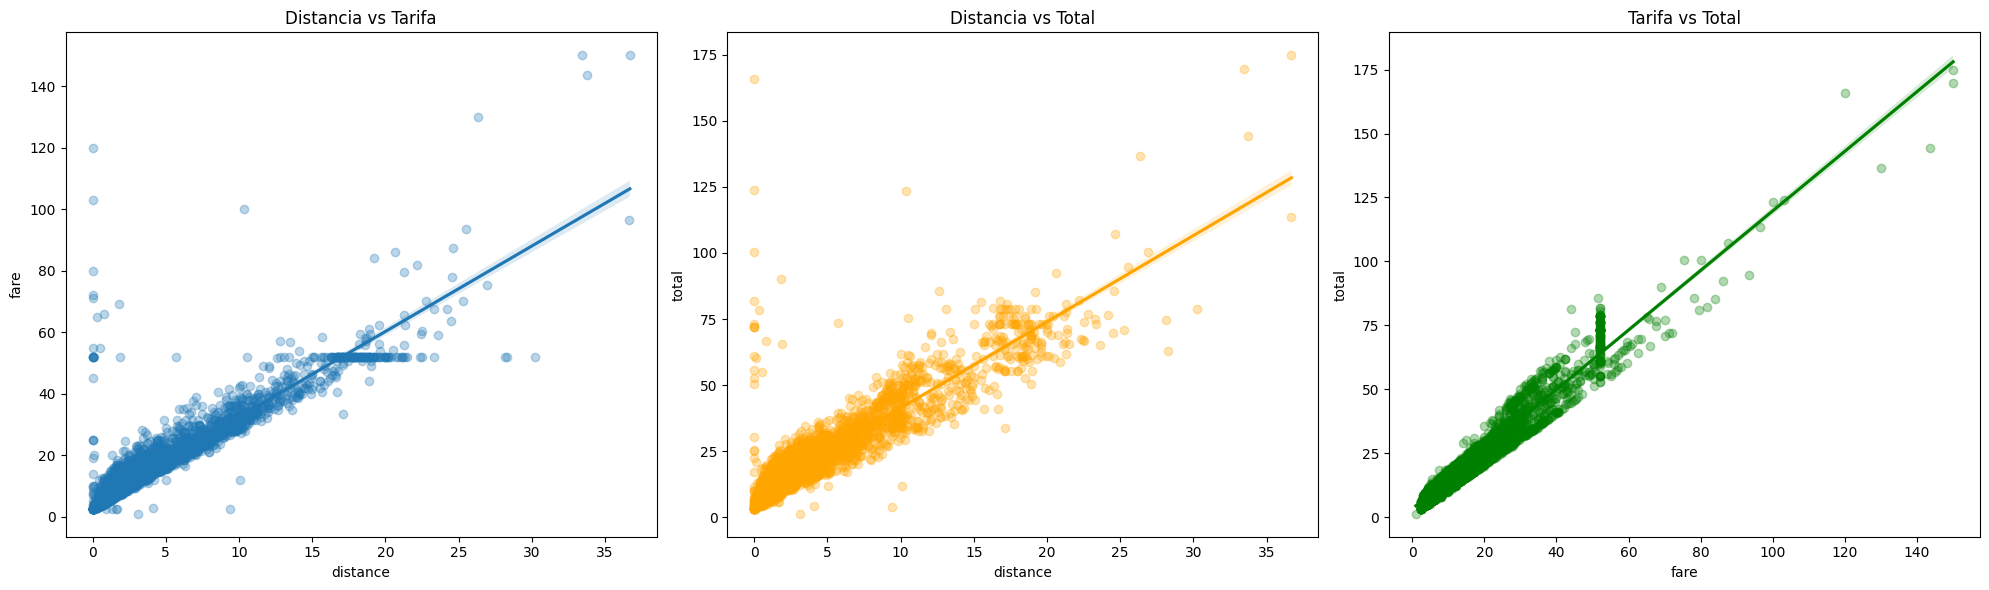

In [ ]:
# 1. Importar librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Importar el dataset de taxis
df_taxis = sns.load_dataset('taxis')

# 3. Datos generales
print("--- Propiedades del Dataset ---")
print(df_taxis.info())
print("\n--- Resumen Estadístico ---")
print(df_taxis.describe())

# 4. Análisis Univariable: La columna 'total' (Lo que paga el cliente)
total_data = df_taxis['total'].dropna() # Limpiamos nulos para el cálculo

# Medidas de tendencia central
media = total_data.mean()
mediana = total_data.median()
moda = total_data.mode()[0]

# Medidas de dispersión
desviacion = np.std(total_data)
varianza = np.var(total_data)

# Visualización Univariable
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(total_data, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Totales')
axes[0].axvline(media, color='red', linestyle='--', label='Media')

# Boxplot (Para ver valores atípicos o viajes muy caros)
sns.boxplot(x=total_data, ax=axes[1], color='lightgreen')
axes[1].set_title('Caja y Bigotes: Totales')

# Violin Plot (Densidad del costo de viajes)
sns.violinplot(x=total_data, ax=axes[2], color='salmon')
axes[2].set_title('Densidad de Totales')

plt.tight_layout()
plt.show()

# 5. Análisis Multivariable: Mapa de Calor (Correlación)
plt.figure(figsize=(10, 8))
# Filtramos solo columnas numéricas
corr_matrix = df_taxis.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación de la Flota de Taxis')
plt.show()

# 6. Análisis Bivariable: Las 3 correlaciones más fuertes
# Basado en el heatmap, las más fuertes suelen ser:
# 1. distance vs fare (distancia vs tarifa base)
# 2. distance vs total (distancia vs total final)
# 3. fare vs total (tarifa base vs total final)

correlaciones = {
    "Distancia vs Tarifa": df_taxis['distance'].corr(df_taxis['fare']),
    "Distancia vs Total": df_taxis['distance'].corr(df_taxis['total']),
    "Tarifa vs Total": df_taxis['fare'].corr(df_taxis['total'])
}

print("\n--- Coeficientes de Pearson ---")
for key, value in correlaciones.items():
    print(f"{key}: {value:.4f}")

# Visualización Bivariable en 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.regplot(data=df_taxis, x='distance', y='fare', ax=axes[0], scatter_kws={'alpha':0.3})
axes[0].set_title('Distancia vs Tarifa')

sns.regplot(data=df_taxis, x='distance', y='total', ax=axes[1], scatter_kws={'alpha':0.3}, color='orange')
axes[1].set_title('Distancia vs Total')

sns.regplot(data=df_taxis, x='fare', y='total', ax=axes[2], scatter_kws={'alpha':0.3}, color='green')
axes[2].set_title('Tarifa vs Total')

plt.tight_layout()
plt.show()

# Estadística Inferencial

La estadística inferencial es la rama de la estadística que permite tomar decisiones o sacar conclusiones sobre una población completa usando únicamente una muestra de datos.

*La estadística inferencial se usa en:*


*   Medicina
*   Negocios
*   Marketing
*   Inteligencia artificial
*   Finanzas
*   Deportes
*   Psicología
* Educación




**Prueba de Hipótesis**

Es un procedimiento formal que permite validar afirmaciones sobre una población a partir de una muestra de datos.

*Se basa en comparar dos hipótesis:*

**Hipótesis Nula** ($H_0$): Es la suposición por defecto, indicando que "no hay efecto" o "no hay diferencia".

**Hipótesis Alternativa** ($H_1$): Es lo que buscamos probar, indicando que "existe una diferencia".  

**Nivel de Significancia **($\alpha$): El umbral de error aceptable (comúnmente 0.05 o 5%).  

**P-Value**: Si es menor a $\alpha$, rechazamos $H_0$ porque hay evidencia estadística suficiente de un cambio.

# Ejercicio 2:

Se desea evaluar si un producto químico es más efectivo para eliminar chinches que cucarachas. Para ello, se realizaron 10 aplicaciones en grupos de 100 insectos de cada tipo, registrando el número de muertes en cada caso. Con estos datos, se plantea la hipótesis de que el producto extermina en promedio más chinches que cucarachas, y se busca evidencia estadística para comprobarlo.

Visualizacion:

**Ejercicio**

Quieres saber si un nuevo fertilizante realmente hace que las plantas crezcan más que el fertilizante estándar.

Usaremos scipy.stats.ttest_ind, que es la función para comparar las medias de dos grupos independientes.

# Análisis de Predictivo de Datos

Utiliza datos históricos, algoritmos de machine learning y modelos estadísticos para pronosticar eventos futuros y comportamientos probables. Esta rama avanzada de analítica permite a las empresas identificar riesgos y oportunidades, optimizar operaciones y mejorar la toma de decisiones, pasando de entender el pasado a anticipar el futuro

**Regresión Lineal**



La regresión lineal es una técnica estadística utilizada para comprender la relación entre una variable independiente (o predictora) y una variable dependiente (o respuesta). En términos más simples, busca modelar cómo cambia una variable (la dependiente) en función de otra variable (la independiente).

Fórmula de regresión lineal
La regresión lineal es una técnica estadística utilizada para comprender la relación entre una variable independiente (o predictora) y una variable dependiente (o respuesta).

La fórmula de la regresión lineal se expresa matemáticamente como:

**Y = β0 + β1X + ε**

Donde:

•	Y es la variable dependiente que queremos predecir.

•	X es la variable independiente que usamos para hacer la predicción.

•	β0 es la intersección de la línea de regresión con el eje Y.

•	β1 es la pendiente de la línea de regresión.

•	ε es el término de error.


# Regresión lineal

La regresión lineal simple se utiliza para estimar la relación entre dos variables cuantitativas .

 Puedes usar la regresión lineal simple cuando quieras saber:

Qué tan fuerte es la relación entre dos variables (por ejemplo, la relación entre la lluvia y la erosión del suelo).

El valor de la variable dependiente para un determinado valor de la variable independiente (por ejemplo, la cantidad de erosión del suelo a un determinado nivel de precipitación).

**Ejercicio:**

Eres un investigador social interesado en la relación entre ingresos y felicidad. Realizas una encuesta a 500 personas cuyos ingresos oscilan entre 15.000 y 75.000 y les pides que califiquen su felicidad en una escala del 1 al 10.
Tanto la variable independiente (ingresos) como la variable dependiente (felicidad) son cuantitativas, por lo que se puede realizar un análisis de regresión para comprobar si existe una relación lineal entre ellas